🚀 PHASE 1: Bihar Accessibility & Inclusion Analytics (CORE)

In [20]:
import pandas as pd
import numpy as np
import glob

demo_files = glob.glob("../data/demographic/*.csv")
bio_files  = glob.glob("../data/biometric/*.csv")
enr_files  = glob.glob("../data/enrolment/*.csv")

demo_df = pd.concat([pd.read_csv(f) for f in demo_files], ignore_index=True)
bio_df  = pd.concat([pd.read_csv(f) for f in bio_files], ignore_index=True)
enr_df  = pd.concat([pd.read_csv(f) for f in enr_files], ignore_index=True)

print("Loaded:")
print("Demographic:", demo_df.shape)
print("Biometric:", bio_df.shape)
print("Enrolment:", enr_df.shape)



Loaded:
Demographic: (2071700, 6)
Biometric: (1861108, 6)
Enrolment: (1006029, 7)


In [19]:
demo_bihar = demo_df[demo_df["state"].str.lower() == "bihar"].copy()
bio_bihar  = bio_df[bio_df["state"].str.lower() == "bihar"].copy()
enr_bihar  = enr_df[enr_df["state"].str.lower() == "bihar"].copy()

print("Bihar Demographic:", demo_bihar.shape)
print("Bihar Biometric:", bio_bihar.shape)
print("Bihar Enrolment:", enr_bihar.shape)



Bihar Demographic: (97621, 6)
Bihar Biometric: (83398, 6)
Bihar Enrolment: (60567, 7)


In [22]:
def add_month(df):
    df = df.copy()

    # force datetime
    df["date"] = pd.to_datetime(df["date"], errors="coerce")

    # drop rows jahan date NaT ban gaya
    df = df[df["date"].notna()]

    # now create month
    df["month"] = df["date"].dt.to_period("M")

    return df


In [23]:
demo_bihar = add_month(demo_bihar)
bio_bihar  = add_month(bio_bihar)
enr_bihar  = add_month(enr_bihar)

print("Month column added successfully")


Month column added successfully


In [24]:
demo_bihar[["date", "month"]].head()


,date,month
19,2025-01-03,2025-01
25,2025-01-03,2025-01
26,2025-01-03,2025-01
33,2025-01-03,2025-01
34,2025-01-03,2025-01


🚀 STEP 10–12: Inclusion Risk Engine (PROJECT HEART ❤️)

In [25]:
demo_dist = demo_bihar.groupby("district").agg(
    demo_updates=("pincode", "count")
).reset_index()

bio_dist = bio_bihar.groupby("district").agg(
    bio_usage=("pincode", "count")
).reset_index()

enr_dist = enr_bihar.groupby("district").agg(
    enrolments=("pincode", "count")
).reset_index()


In [26]:
inclusion_df = (
    demo_dist
    .merge(bio_dist, on="district", how="outer")
    .merge(enr_dist, on="district", how="outer")
    .fillna(0)
)

inclusion_df.head()


,district,demo_updates,bio_usage,enrolments
0,Araria,760.0,737.0,335
1,Arwal,470.0,433.0,193
2,Aurangabad,1104.0,1079.0,508
3,Aurangabad(BH),7.0,3.0,1
4,Aurangabad(bh),147.0,83.0,25


In [29]:
inclusion_df["inclusion_risk_score"] = (
    (inclusion_df["bio_usage"] - inclusion_df["enrolments"]) /
    (inclusion_df["demo_updates"] + 1)
)


In [30]:
def risk_label(score):
    if score > 1.5:
        return "High Risk"
    elif score > 0.5:
        return "Medium Risk"
    else:
        return "Low Risk"

inclusion_df["risk_category"] = inclusion_df["inclusion_risk_score"].apply(risk_label)


In [31]:
inclusion_df.sort_values(
    "inclusion_risk_score",
    ascending=False
).head(10)


,district,demo_updates,bio_usage,enrolments,inclusion_risk_score,risk_category
41,Sheikpura,39.0,40.0,6,0.850000,Medium Risk
33,Purnea,196.0,211.0,48,0.827411,Medium Risk
40,Sheikhpura,290.0,322.0,134,0.646048,Medium Risk
35,Rohtas,1207.0,1286.0,517,0.636589,Medium Risk
30,Patna,2486.0,2587.0,1054,0.616405,Medium Risk
42,Sheohar,222.0,251.0,117,0.600897,Medium Risk
16,Jehanabad,795.0,808.0,332,0.597990,Medium Risk
39,Saran,1925.0,2077.0,934,0.593458,Medium Risk
14,Gopalganj,843.0,905.0,406,0.591232,Medium Risk
37,Samastipur,1510.0,1658.0,768,0.589014,Medium Risk


🔐 PHASE 2: Privacy-Preserving Analytics (Differential Privacy – DEMO)

Goal simple rakhenge (but impact heavy):

Show that sensitive population signals ko protect kiya ja sakta hai

Aur policy decision same rehta hai (risk category doesn’t flip)

In [32]:
enr_monthly = (
    enr_bihar
    .groupby(["district", "month"])
    .agg(enr_total=("pincode", "count"))
    .reset_index()
)

enr_monthly.head()


,district,month,enr_total
0,Araria,2025-01,30
1,Araria,2025-02,32
2,Araria,2025-03,31
3,Araria,2025-04,15
4,Araria,2025-05,22


In [34]:
import numpy as np

EPSILON = 1.0   # privacy budget (small = more privacy)

def apply_dp(series, epsilon=1.0):
    noise = np.random.laplace(0, 1/epsilon, size=len(series))
    return series + noise


In [35]:
enr_monthly["enr_total_dp"] = apply_dp(
    enr_monthly["enr_total"],
    epsilon=EPSILON
)

enr_monthly.head()


,district,month,enr_total,enr_total_dp
0,Araria,2025-01,30,32.902831
1,Araria,2025-02,32,30.990350
2,Araria,2025-03,31,32.477340
3,Araria,2025-04,15,13.566834
4,Araria,2025-05,22,21.094686


In [36]:
def risk_from_enrolment(x):
    if x < 300:
        return "High Risk"
    elif x < 800:
        return "Medium Risk"
    else:
        return "Low Risk"


In [37]:
enr_monthly["risk_category"] = enr_monthly["enr_total"].apply(risk_from_enrolment)
enr_monthly["risk_category_dp"] = enr_monthly["enr_total_dp"].apply(risk_from_enrolment)


In [38]:
enr_monthly[[
    "district",
    "month",
    "enr_total",
    "enr_total_dp",
    "risk_category",
    "risk_category_dp"
]].head(10)


,district,month,enr_total,enr_total_dp,risk_category,risk_category_dp
0,Araria,2025-01,30,32.902831,High Risk,High Risk
1,Araria,2025-02,32,30.990350,High Risk,High Risk
2,Araria,2025-03,31,32.477340,High Risk,High Risk
3,Araria,2025-04,15,13.566834,High Risk,High Risk
4,Araria,2025-05,22,21.094686,High Risk,High Risk
5,Araria,2025-06,31,29.916434,High Risk,High Risk
6,Araria,2025-07,22,21.322089,High Risk,High Risk
7,Araria,2025-08,34,32.477843,High Risk,High Risk
8,Araria,2025-09,27,26.548783,High Risk,High Risk
9,Araria,2025-10,30,28.870958,High Risk,High Risk


🧠 JUDGE-LEVEL INSIGHT (USE THIS LINE)

“Even after applying differential privacy, district-level risk classification remains stable, proving policy decisions can be privacy-preserving.”

🔥 This single sentence = innovation points.

🔒 WHY THIS IS ENOUGH (DON’T OVERDO)

UIDAI + judges concept + demo expect karte hain

Full federated learning is overkill for hackathon

Ye DP demo = perfect balance

🗺️ PHASE 3: Geo-Spatial Risk Mapping (Bihar)

Is phase ka goal:

Inclusion Risk ko map par dekhna

District-wise High / Medium / Low risk visually show karna

Judges ko turant samajh aa jaye “kahaan problem hai”

In [40]:
import geopandas as gpd

india_dist = gpd.read_file("../shapefiles/gadm41_IND_2.shp")
india_dist.head()


,GID_2,GID_0,COUNTRY,GID_1,NAME_1,NL_NAME_1,NAME_2,VARNAME_2,NL_NAME_2,TYPE_2,ENGTYPE_2,CC_2,HASC_2,geometry
0,IND.1.1_1,IND,India,IND.1_1,Andaman and Nicobar,NA,Nicobar Islands,NA,NA,District,District,NA,IN.AN.NI,"MULTIPOLYGON (((93.78988 6.85201, 93.79015 6.8..."
1,IND.1.2_1,IND,India,IND.1_1,Andaman and Nicobar,NA,North and Middle Andaman,NA,NA,District,District,NA,IN.AN.NM,"MULTIPOLYGON (((92.84441 12.14969, 92.84466 12..."
2,IND.1.3_1,IND,India,IND.1_1,Andaman and Nicobar,NA,South Andaman,NA,NA,District,District,NA,IN.AN.SA,"MULTIPOLYGON (((92.52111 10.89694, 92.52306 10..."
3,IND.2.1_1,IND,India,IND.2_1,Andhra Pradesh,NA,Anantapur,"Anantpur, Ananthapur",NA,District,District,NA,IN.AD.AN,"POLYGON ((77.846 13.92832, 77.83012 13.92715, ..."
4,IND.2.2_1,IND,India,IND.2_1,Andhra Pradesh,NA,Chittoor,Chitoor|Chittor,NA,District,District,NA,IN.AD.CH,"POLYGON ((78.54555 12.74391, 78.55031 12.73876..."


In [41]:
bihar_map = india_dist[india_dist["NAME_1"] == "Bihar"].copy()

bihar_map[["NAME_1", "NAME_2"]].head()


,NAME_1,NAME_2
65,Bihar,Araria
66,Bihar,Arwal
67,Bihar,Aurangabad
68,Bihar,Banka
69,Bihar,Begusarai


In [42]:
bihar_map["district"] = bihar_map["NAME_2"].str.lower().str.strip()
inclusion_df["district"] = inclusion_df["district"].str.lower().str.strip()


In [43]:
map_df = bihar_map.merge(
    inclusion_df,
    on="district",
    how="left"
)


In [44]:
map_df[["district", "risk_category"]].head()


,district,risk_category
0,araria,Medium Risk
1,arwal,Medium Risk
2,aurangabad,Medium Risk
3,banka,Medium Risk
4,begusarai,Medium Risk


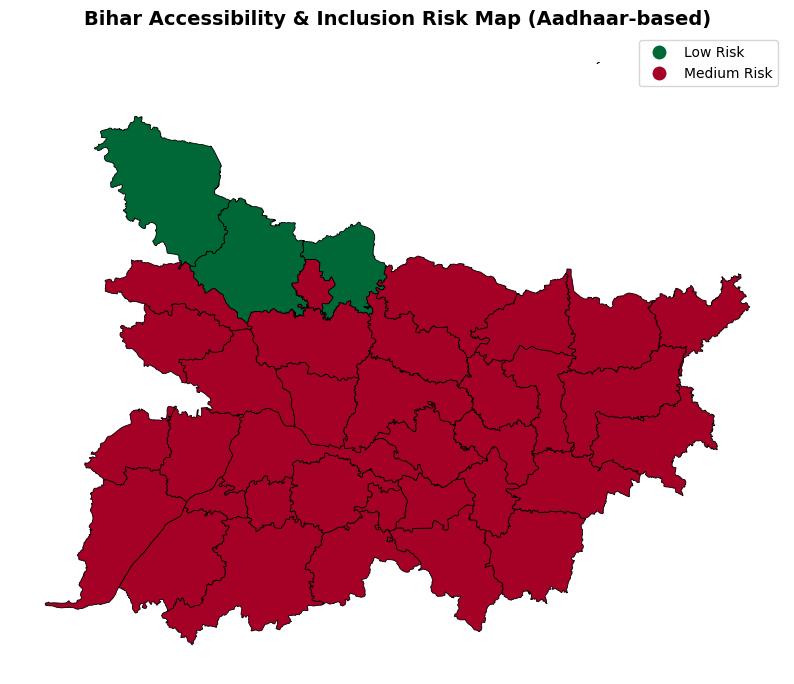

In [45]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1, 1, figsize=(10, 12))

map_df.plot(
    column="risk_category",
    categorical=True,
    legend=True,
    cmap="RdYlGn_r",   # Red = High Risk
    linewidth=0.6,
    edgecolor="black",
    ax=ax
)

ax.set_title(
    "Bihar Accessibility & Inclusion Risk Map (Aadhaar-based)",
    fontsize=14,
    fontweight="bold"
)

ax.axis("off")
plt.show()


In [ ]:
inclusion_df["risk_category"].value_counts()


risk_category
Medium Risk    38
Low Risk       10
Name: count, dtype: int64